In [15]:
import langgraph
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from dotenv import load_dotenv
from pydantic import BaseModel,Field
import operator

In [2]:
load_dotenv()
import os
key = os.getenv("gemini_api")

In [3]:
import langchain_google_genai 
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=key,
    temperature=0.7
)

In [6]:
class EvaluationSchema(BaseModel):
    feedback:str = Field(description='Detailed feedback for the essay')
    score:int = Field(description='Score out of 10',ge=0,le=10)

In [7]:
s_model = model.with_structured_output(EvaluationSchema)

In [8]:
essay = """
"Power tends to corrupt, and absolute power corrupts absolutely."
It is not easy to define corruption. But in a narrow sense, corruption is mostly concerned with "bribery" and it takes several forms. Corruption today is a world-wide phenomenon and India is one of the most corrupt nations in the world.

Corruption is an indication of decadence. A corrupt person is termed immoral and dishonest. Only a person with greatly eroded values indulges in corruption.

The problem with corruption is that it threatens the very existence of the society . Corruption is like a leech draining the blood of the society. The worst part is that it affects every part of human life: the flourishing black market in essential commodities, adulteration of even food, bribe, fraud and economic, political and administrative manipulations etc have made the people feel greatly miserable and helpless.

We can trace corruption to ancient times. Kautilya, the author of the Arthasastra pointed out corruption of his times. He also talked about the inevitability of corruption. He had said, "Just as it is impossible not to taste the honey or the poison that finds itself at the tip of the tongue, so it is impossible for a government servant not to eat up at least a bit of the king's revenue. These in the postwar world became only bolder while eating up government money and accepting bribes.

Today, although India is free, the government officials have enslaved the general public with their corruption. Most of them are hand in gloves with businessmen and thus the whole system is corrupt. What starts at the top percolates down to the lowest rungs of the society. It has thus become widespread even in villages.

The situation is so bad that it looks like India will never get rid of corruption.
"""

In [9]:
prompt = f"Evaluate the language quality of the essay and provide a feedback and score out of 10 \n {essay}"
out = s_model.invoke(prompt)

In [13]:
out

EvaluationSchema(feedback="The essay effectively introduces the topic of corruption and uses a powerful opening quote. The language is generally clear and easy to understand, conveying the main points directly. You use some good vocabulary, such as 'decadence' and 'percolates down'. However, there are several areas where the language could be improved for greater precision and sophistication. You frequently miss articles (e.g., 'the society' instead of 'society'), which is a recurring grammatical error. Some sentences are overly long and list-like, making them a bit clunky (e.g., the sentence describing the effects of corruption). The phrasing can sometimes be awkward ('adulteration of even food', 'bribe, fraud and economic... manipulations etc have made'). Most notably, the paragraph discussing Kautilya has a significant issue with coherence and logic; the sudden jump to 'These in the postwar world' is jarring and unconnected to the preceding historical context, creating confusion. Ad

# State

In [16]:
class EState(TypedDict):
    essay:str
    l_fb:str
    a_fb:str
    c_fb:str
    o_fb:str
    indiv_scores: Annotated[list[int],operator.add]
    final_score:float

# Graph

In [ ]:
def e_language(state: EState):
    prompt = f"Evaluate the language quality of the essay and provide a feedback and score out of 10 \n {state['essay']}"
    out = s_model.invoke(prompt)
    return {'l_fb':out.feedback,'indiv_scores':[out.score]}

def e_analysis(state: EState):
    prompt = f"Evaluate the depth of analysis of the essay and provide a feedback and score out of 10 \n {state['essay']}"
    out = s_model.invoke(prompt)
    return {'a_fb':out.feedback,'indiv_scores':[out.score]}

def e_clarity(state: EState):
    prompt = f"Evaluate the clarity of thought of the essay and provide a feedback and score out of 10 \n {state['essay']}"
    out = s_model.invoke(prompt)
    return {'c_fb':out.feedback,'indiv_scores':[out.score]}



In [27]:
def final(state:EState):
    prompt = f"Based on the following feedbacks generate a summarized feedback \n {state['l_fb']} \n {state['a_fb']} \n {state['c_fb']}"
    o_fb = model.invoke(prompt).content

    fscore = sum(state['indiv_scores'])/len(state['indiv_scores'])
    return {'o_fb':o_fb,'final_score':fscore}

In [28]:
graph = StateGraph(EState)

graph.add_node('e_language',e_language)
graph.add_node('e_analysis',e_analysis)
graph.add_node('e_clarity',e_clarity)
graph.add_node('final',final)

graph.add_edge(START,'e_language')
graph.add_edge(START,'e_analysis')
graph.add_edge(START,'e_clarity')

graph.add_edge('e_language','final')
graph.add_edge('e_analysis','final')
graph.add_edge('e_clarity','final')

graph.add_edge('final',END)

wf = graph.compile()

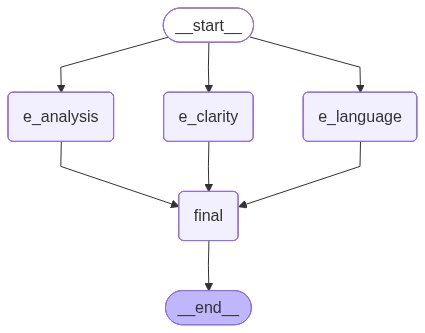

In [23]:
wf

In [29]:
out = wf.invoke({'essay':essay})

In [31]:
print(out['o_fb'])

Here's a summarized feedback based on the provided comments:

The essay successfully provides a clear and coherent overview of corruption, effectively defining it, highlighting its societal impact, and tracing its historical presence. The opening quote and the 'leech' metaphor are particularly effective, and the inclusion of Kautilya's perspective adds valuable historical context.

However, several key areas require significant enhancement to elevate the essay's overall quality and analytical depth. The most prominent feedback points to a **superficial level of analysis**. While the essay identifies the problem and its effects, it largely remains descriptive, relying on broad generalizations about corruption in India without offering specific examples, supporting data, or a deeper exploration of underlying causes, mechanisms, or systemic factors. There is a lack of nuanced discussion regarding the complexities or various forms of corruption. Crucially, the essay does not delve into pot

In [32]:
print(out['final_score'])

6.0
